# Find TC genesis lag KW in ace2 (2001-2010, 100yr)

This code is adapated from TCgenesis_lagKW_10yr.ipynb

Only summer is used (NDJFMA for SH, MJJASO for NH)

Mu-Ting Chien

2025.3.4

In [2]:
import numpy as np
from netCDF4 import Dataset
import xarray as xr
import os
import sys
sys.path.append('/barnes-engr-scratch1/c832572266/Function/')
import mjo_mean_state_diagnostics_uw as MJO
#
sys.path.append('/home/C832572266/code/function/')
import KW_diagnostics_new as KW
import matplotlib.pyplot as plt
import cartopy.util as cartopy_util
import cartopy.crs as ccrs
from datetime import datetime, timezone
from scipy.stats import binom

In [6]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_obs_ace2      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_ace2          = DIR + 'data_output/ace2/ace2_output/10yr/'
file_dir_ace2_100yr    = DIR + 'data_output/ace2/ace2_output/repeat_2001-2010/'
fig_dir                = DIR + 'figure/ace2_fig/kw_TC_summer_only/' # Reomte direcotry for figures 
os.makedirs(fig_dir, exist_ok=True)
expname_list  = list(['ace2','era5'])
expname2_list = list(['ace2','imerg'])

# Parameters used for KW phase composite
pi  = np.pi
dph = 1/8*np.pi
mybin = np.arange(-pi, pi+dph*2, dph)-dph/2 #play around this 1/8
phase_bin = mybin[:-1] + dph/2
PI = '\u03C0'
bin_simple = np.arange(-pi,pi+1/4*pi,1/4*pi)
y2d = 365.25

# Mutual bin for TC genesis lag KW crest
hr_bin = np.arange(-126, 126, 6)+3
hr_bin_12h = np.arange(-132, 144, 12)+6
hr_bin_daily = np.arange(-8.5, 9.5, 1)

sub_dir = list(['2001','2002','2003','2004','2005','2006','2007','2008','2009','2010'])
nsub    = np.size(sub_dir)

# Load KW peak and TC genesis

In [11]:
# For each TC genesis event, find the timing of the closest KW peak at the genesis location

for isub in range(0, nsub):
    
    print(sub_dir[isub])
    file_dir_sub = file_dir_ace2_100yr + sub_dir[isub] + '/'
    
    # 1. Load KW phase data 
    data          = np.load(file_dir_sub+'pr_kw-phase_ace2_'+sub_dir[isub]+'_10yr_10SN.npz')
    phase_correct_10S = data['phase_correct_ace2_10S']
    phase_correct_10N = data['phase_correct_ace2_10N']
    time_filt     = data['time_filt']
    #time_phase_ace2 = time_ace2[time_filt]
    lon_ace2 = data['lon']
    nlon_ace2 = np.size(lon_ace2)

    # 2. Find KW crest (the enhanced KW phase)
    KW_crest_ace2_10S = np.where(phase_correct_10S==-pi/2, 1, 0)
    KW_crest_ace2_10N = np.where(phase_correct_10N==-pi/2, 1, 0)

    # 3. Load TC data (data output is from Tropical_wave_filtering_ace2_100yr.ipynb)
    data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+sub_dir[isub]+'.npz')
    TC_genesis_txy_ace2 = data['TC_genesis_txy'] # code above this section sets this variable as TC_genesis_txy
    it_ace2_new         = data['it']
    ilat_ace2_new       = data['ilat']
    ilon_ace2_new       = data['ilon']

    if isub == 0: # time and lat information is the same for all data, so no need to keep importing this
        # 4. Load real time (yyyy-mm-dd-hh)
        ds = xr.open_dataset(file_dir_sub + 'pr_kwfilt_15SN_ace2_2001-2010_2.5deg.nc')
        time_ace2 = ds['time'].values
        #print(time_ace2)

        # 5. Load lat (1deg * 1deg)
        data = np.load(file_dir_sub+'pr_kwfilt_ace2.npz')  
        lat_15SN_ace2 = data['lat_15SN']
        #print(lat_15SN_ace2)

        # 6. Find month for each time of the entire kw (phase) timeseries
        month_ace2 = time_ace2.astype('datetime64[M]').astype(int) % 12 + 1
        #print(month_ace2)
    
    #########################
    # 7. Only select the KW crest that are in summer (MJJASO in NH and NDJFMA in SH)
    # Transform the month array so that <6 is NH summer and >=6 is SH summer
    month_ace2_tmp = month_ace2 - 5
    month_ace2_tmp = np.where(month_ace2_tmp<0, month_ace2_tmp+12, month_ace2_tmp)
    month_ace2_tmp = np.tile(month_ace2_tmp, (nlon_ace2, 1)).T
    #
    KW_crest_ace2_10S_summer  = np.where(month_ace2_tmp>=6, KW_crest_ace2_10S, 0)
    KW_crest_ace2_10N_summer  = np.where(month_ace2_tmp<6, KW_crest_ace2_10N, 0)

    #####################
    # 8. Find the lag between TC genesis and the closest KW crest
    iexp = 0
    expname  = expname_list[iexp]
    expname2 = expname2_list[iexp]
    ilat     = globals()['ilat_'+expname+'_new']
    ilon     = globals()['ilon_'+expname+'_new']
    it       = globals()['it_'+expname+'_new']

    for i in range(0, np.size(ilat)): # for each TC genesis event
        if ilat[i] > 15: # NH
            KW_crest = globals()['KW_crest_'+expname2+'_10N_summer']
        else:
            KW_crest = globals()['KW_crest_'+expname2+'_10S_summer']
        KW_crest_it = np.argwhere(KW_crest[:,ilon[i]]==1).squeeze()
        if i == 0:
            dhr = np.empty([np.size(ilat)])
        if np.size(KW_crest_it)==0:
            dhr[i] = np.nan
        else:
            dt = (it[i]-KW_crest_it)*6
            dhr[i] = np.min(np.abs(dt)) # how many hours after KW crest that TC genesis occurs
            ihr = np.argwhere(np.abs(dt)==dhr[i]).squeeze()
            if np.size(ihr)>1:
                ihr = ihr[0]
            if it[i] - KW_crest_it[ihr] <0:
                dhr[i] = -dhr[i]

            if i < 2 and isub == 0: # Print results to make sure they are reasonable 
                print('KW_crest_it:',KW_crest_it[ihr])
                print('it:',it[i])
                print('dhr:', dhr[i])
                print('-------------')
    if iexp == 0:
        dhr_ace2_10SN = dhr

    # Save output
    np.savez(file_dir_sub+'TCgenesis_lag_kwcrest_hr_10SN_summer_only_ace2_10yr_'+sub_dir[isub]+'.npz',\
            dhr_ace2_10SN=dhr_ace2_10SN)

2001
KW_crest_it: 153
it: 38
dhr: -690.0
-------------
KW_crest_it: 75
it: 70
dhr: -30.0
-------------
2002
2003
2004
2005
2006
2007
2008
2009
2010


# TC genesis lags KW days in each basin

In [10]:
# Load basin info
basin_list    = list(['NI','NWPAC','NEPAC','NATL','SI','SPAC'])
basin_long_list = list(['North IO','North WestPac','North EastPac','North Atl','South IO','South Pac'])
basin_lon_min = np.array([45, 105, 180, 265, 35, 135])
basin_lon_max = np.array([105, 180, 265, 357.5, 135, 270])
latmax = 30 #25 is not used, use 30
basin_lat_min = np.array([0,    0,    0,  0,  -latmax, -latmax])
basin_lat_max = np.array([latmax,  latmax, latmax, latmax,    0, 0])
nbasin        = np.size(basin_list)

In [46]:
# For each TC genesis event, find the basin index
find_basin = 0
if find_basin == 1:
    nsub = 10
    for isub in range(0, nsub):

        yrname = sub_dir[isub]
        print(yrname)
        file_dir_sub = file_dir_ace2_100yr+yrname+'/'

        # Load TC data
        data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+yrname+'.npz')
        TC_genesis_txy_ace2 = data['TC_genesis_txy']
        ilat_ace2_new       = data['ilat']
        ilon_ace2_new       = data['ilon']
        it_ace2_new         = data['it']
        nlat_ace2           = np.size(lat_15SN_ace2)

        TC_genesis_tx_ace2  = np.sum(TC_genesis_txy_ace2, 1)
        dlat0               = lat_15SN_ace2-0.5
        ilat0               = np.argwhere( np.abs(dlat0) == np.min(np.abs(dlat0))).squeeze()
        TC_genesis_tx_ace2_0_10N  = np.sum(TC_genesis_txy_ace2[:,ilat0:,:], 1)
        TC_genesis_tx_ace2_0_10S  = np.sum(TC_genesis_txy_ace2[:,:ilat0,:], 1)
        nlat_0_10N_ace2           = np.size(lat_15SN_ace2[ilat0:])
        nlat_0_10S_ace2           = np.size(lat_15SN_ace2[:ilat0])
        nlat_ace2                 = np.size(lat_15SN_ace2)

        expname = 'ace2'    
        ilat     = globals()['ilat_'+expname+'_new']
        ilon     = globals()['ilon_'+expname+'_new']
        it       = globals()['it_'+expname+'_new']
        basin_idx = np.zeros(np.size(it))
        basin_idx[:] = np.nan

        # Find which basin does each TC genesis event falls into
        for i in range(0, np.size(ilat)): # for each TC genesis event
            for ibasin in range(0, nbasin):
                ilat_int = int(ilat[i])
                ilon_int = int(ilon[i])
                dlatmin = lat_15SN_ace2[ilat_int]-basin_lat_min[ibasin]
                dlatmax = lat_15SN_ace2[ilat_int]-basin_lat_max[ibasin]
                dlonmin = lon_ace2[ilon_int]-basin_lon_min[ibasin]
                dlonmax = lon_ace2[ilon_int]-basin_lon_max[ibasin]
                #print(dlatmin, dlatmax)
                #print(dlonmin, dlonmax)
                if dlatmin*dlatmax<0 and dlonmin*dlonmax<0:
                    basin_idx[i] = ibasin
                    #print(lat_15SN_ace2[ilat_int], lon_ace2[ilon_int], basin_list[ int(basin_idx[i])])
                    continue

        # Save basin index
        np.savez(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+yrname+'.npz',\
                TC_genesis_txy=TC_genesis_txy_ace2, it =it_ace2_new, ilat=ilat_ace2_new, ilon=ilon_ace2_new,\
                    basin_idx = basin_idx)

In [15]:
# Find the timing of the closest KW crest for each TC genesis event for each basin
for isub in range(0, nsub):

    yrname = sub_dir[isub]
    print(yrname)
    file_dir_sub = file_dir_ace2_100yr+yrname+'/'

    # Load TC genesis data
    data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+yrname+'.npz')
    basin_idx           = data['basin_idx']
    print(np.size(basin_idx))

    # Load dhr 
    data = np.load(file_dir_sub+'TCgenesis_lag_kwcrest_hr_10SN_summer_only_ace2_10yr_'+sub_dir[isub]+'.npz')
    dhr_ace2 = data['dhr_ace2_10SN']

    dhr_ace2_basin0 = np.where(basin_idx==0, dhr_ace2,  np.nan)
    dhr_ace2_basin0 = dhr_ace2_basin0[np.isnan(dhr_ace2_basin0)==0]
    #
    dhr_ace2_basin1 = np.where(basin_idx==1, dhr_ace2,  np.nan)
    dhr_ace2_basin1 = dhr_ace2_basin1[np.isnan(dhr_ace2_basin1)==0]
    #
    dhr_ace2_basin2 = np.where(basin_idx==2, dhr_ace2,  np.nan)
    dhr_ace2_basin2 = dhr_ace2_basin2[np.isnan(dhr_ace2_basin2)==0]
    #
    dhr_ace2_basin3 = np.where(basin_idx==3, dhr_ace2,  np.nan)
    dhr_ace2_basin3 = dhr_ace2_basin3[np.isnan(dhr_ace2_basin3)==0]
    #
    dhr_ace2_basin4 = np.where(basin_idx==4, dhr_ace2,  np.nan)
    dhr_ace2_basin4 = dhr_ace2_basin4[np.isnan(dhr_ace2_basin4)==0]
    #
    dhr_ace2_basin5 = np.where(basin_idx==5, dhr_ace2,  np.nan)
    dhr_ace2_basin5 = dhr_ace2_basin5[np.isnan(dhr_ace2_basin5)==0]

    test = 1
    if test == 1:
        # Test only
        print(np.size(dhr_ace2_basin0))
        print(np.size(dhr_ace2_basin1))
        print(np.size(dhr_ace2_basin2))
        print(np.size(dhr_ace2_basin3))
        print(np.size(dhr_ace2_basin4))
        print(np.size(dhr_ace2_basin5))
    print('---------------')
    
    # Save output
    np.savez(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_'+yrname+'_basin_summer_only.npz',\
            dhr_ace2_basin0=dhr_ace2_basin0, dhr_ace2_basin1=dhr_ace2_basin1,\
            dhr_ace2_basin2=dhr_ace2_basin2, dhr_ace2_basin3=dhr_ace2_basin3,\
            dhr_ace2_basin4=dhr_ace2_basin4, dhr_ace2_basin5=dhr_ace2_basin5,\
            basin_list=basin_list)

2001
383
11
147
63
31
56
75
---------------
2002
406
16
155
47
19
75
94
---------------
2003
400
17
138
57
54
64
70
---------------
2004
418
10
174
48
45
70
71
---------------
2005
393
13
128
37
59
76
80
---------------
2006
431
11
148
61
59
75
77
---------------
2007
383
16
139
50
33
89
55
---------------
2008
301
14
78
36
55
78
40
---------------
2009
443
15
135
99
24
104
66
---------------
2010
354
15
73
8
98
84
76
---------------


In [16]:
# Aggregate dhr for each basin for 100 years
i0 = 0
i1 = 0
i2 = 0
i3 = 0
i4 = 0
i5 = 0
for first_time_exe in range( 1, -1, -1):
    for isub in range(0, nsub):
        
        yrname = sub_dir[isub]
        
        data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_'+yrname+'_basin_summer_only.npz')
        dhr_ace2_basin0 = data['dhr_ace2_basin0']
        dhr_ace2_basin1 = data['dhr_ace2_basin1']
        dhr_ace2_basin2 = data['dhr_ace2_basin2']
        dhr_ace2_basin3 = data['dhr_ace2_basin3']
        dhr_ace2_basin4 = data['dhr_ace2_basin4']
        dhr_ace2_basin5 = data['dhr_ace2_basin5']

        # Test only
        test = 0
        if test == 1:
            print(np.size(dhr_ace2_basin0))
            print(np.size(dhr_ace2_basin1))
            print(np.size(dhr_ace2_basin2))
            print(np.size(dhr_ace2_basin3))
            print(np.size(dhr_ace2_basin4))
            print(np.size(dhr_ace2_basin5))
        
        if first_time_exe == 1:
            if isub == 0:
                size_basin_all = np.empty([nsub, nbasin])
            for ibasin in range(0, nbasin):
                tmp = globals()['dhr_ace2_basin'+str(ibasin)]
                size_basin_all[isub,ibasin] = np.size(tmp)
        else:
            if isub == 0:
                dhr_ace2_basin0_100yr = np.empty([ int(np.sum(size_basin_all[:,0],0)) ])
                dhr_ace2_basin1_100yr = np.empty([ int(np.sum(size_basin_all[:,1],0)) ])
                dhr_ace2_basin2_100yr = np.empty([ int(np.sum(size_basin_all[:,2],0)) ])
                dhr_ace2_basin3_100yr = np.empty([ int(np.sum(size_basin_all[:,3],0)) ])
                dhr_ace2_basin4_100yr = np.empty([ int(np.sum(size_basin_all[:,4],0)) ])
                dhr_ace2_basin5_100yr = np.empty([ int(np.sum(size_basin_all[:,5],0)) ])

            dhr_ace2_basin0_100yr[i0:i0+ int(size_basin_all[isub,0]) ] = dhr_ace2_basin0
            dhr_ace2_basin1_100yr[i1:i1+ int(size_basin_all[isub,1]) ] = dhr_ace2_basin1
            dhr_ace2_basin2_100yr[i2:i2+ int(size_basin_all[isub,2]) ] = dhr_ace2_basin2
            dhr_ace2_basin3_100yr[i3:i3+ int(size_basin_all[isub,3]) ] = dhr_ace2_basin3
            dhr_ace2_basin4_100yr[i4:i4+ int(size_basin_all[isub,4]) ] = dhr_ace2_basin4
            dhr_ace2_basin5_100yr[i5:i5+ int(size_basin_all[isub,5]) ] = dhr_ace2_basin5

            i0 = i0 + int( size_basin_all[isub,0] )
            i1 = i1 + int( size_basin_all[isub,1] )
            i2 = i2 + int( size_basin_all[isub,2] )
            i3 = i3 + int( size_basin_all[isub,3] )
            i4 = i4 + int( size_basin_all[isub,4] )
            i5 = i5 + int( size_basin_all[isub,5] )


In [21]:
np.savez(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_basin_summer_only_100yr.npz', \
         dhr_ace2_basin0_100yr = dhr_ace2_basin0_100yr,\
         dhr_ace2_basin1_100yr = dhr_ace2_basin1_100yr,\
         dhr_ace2_basin2_100yr = dhr_ace2_basin2_100yr,\
         dhr_ace2_basin3_100yr = dhr_ace2_basin3_100yr,\
         dhr_ace2_basin4_100yr = dhr_ace2_basin4_100yr,\
         dhr_ace2_basin5_100yr = dhr_ace2_basin5_100yr,\
        basin_list=basin_list)

# Plot TC genesis lag KW days (dhr) for each basin

In [17]:
# Statistical test for each basin

for ibasin in range(0, nbasin):
    print('------------')
    print(basin_list[ibasin])
    dhr_ace2_tmp = globals()['dhr_ace2_basin'+str(ibasin)+'_100yr']
    #dhr_era5_tmp = globals()['dhr_era5_basin'+str(ibasin)]
    
    n_ace2_basin = np.sum(np.abs(dhr_ace2_tmp)<=8.5*24)
    #n_obs_basin  = np.sum(np.abs(dhr_era5_tmp)<=8.5*24)
    print(np.size(dhr_ace2_tmp), n_ace2_basin)
    print(n_ace2_basin)#, n_obs_basin)
    p = 1/(np.size(hr_bin_daily)-1)
    p_6hr = 1/(np.size(hr_bin)-1)
    p_12hr = 1/(np.size(hr_bin_12h)-1)    

    # Find 99.9 percentile
    target_cdf = 0.999
    target_cdf_min = 0.005
    target_cdf_6h = 0.999
    target_cdf_12h = 0.99

    if ibasin == 0:
        x_99_ace2_basin = np.empty([nbasin])
        #x_99_obs_basin = np.empty([nbasin])
        x_99_ace2_6hr_basin = np.empty([nbasin])
        #x_99_obs_6hr_basin = np.empty([nbasin])
        #
        x_99_ace2_12hr_basin = np.empty([nbasin])
        #x_99_obs_12hr_basin = np.empty([nbasin])

    x_99_ace2_basin[ibasin] = binom.ppf(target_cdf, n_ace2_basin, p)
    #x_99_obs_basin[ibasin]  = binom.ppf(target_cdf, n_obs_basin, p)
    x_99_ace2_6hr_basin[ibasin] = binom.ppf(target_cdf_6h, n_ace2_basin, p_6hr)
    #x_99_obs_6hr_basin[ibasin]  = binom.ppf(target_cdf_6h, n_obs_basin, p_6hr)
    #
    x_99_ace2_12hr_basin[ibasin] = binom.ppf(target_cdf_12h, n_ace2_basin, p_12hr)
    #x_99_obs_12hr_basin[ibasin]  = binom.ppf(target_cdf_12h, n_obs_basin, p_12hr)


    print(x_99_ace2_basin[ibasin])#, x_99_obs_basin[ibasin])
    print(x_99_ace2_6hr_basin[ibasin])#, x_99_obs_6hr_basin[ibasin])

------------
NI
138 79
79
12.0
7.0
------------
NWPAC
1315 1007
1007
84.0
41.0
------------
NEPAC
506 490
490
46.0
24.0
------------
NATL
477 422
422
41.0
21.0
------------
SI
771 726
726
63.0
32.0
------------
SPAC
704 662
662
59.0
30.0


In [22]:
# Save significance level
np.savez(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_99.9_significance_level_100yr.npz', \
         x_99_ace2_daily_basin = x_99_ace2_basin,\
         x_99_ace2_6hr_basin = x_99_ace2_6hr_basin,\
         x_99_ace2_12hr_basin = x_99_ace2_12hr_basin)

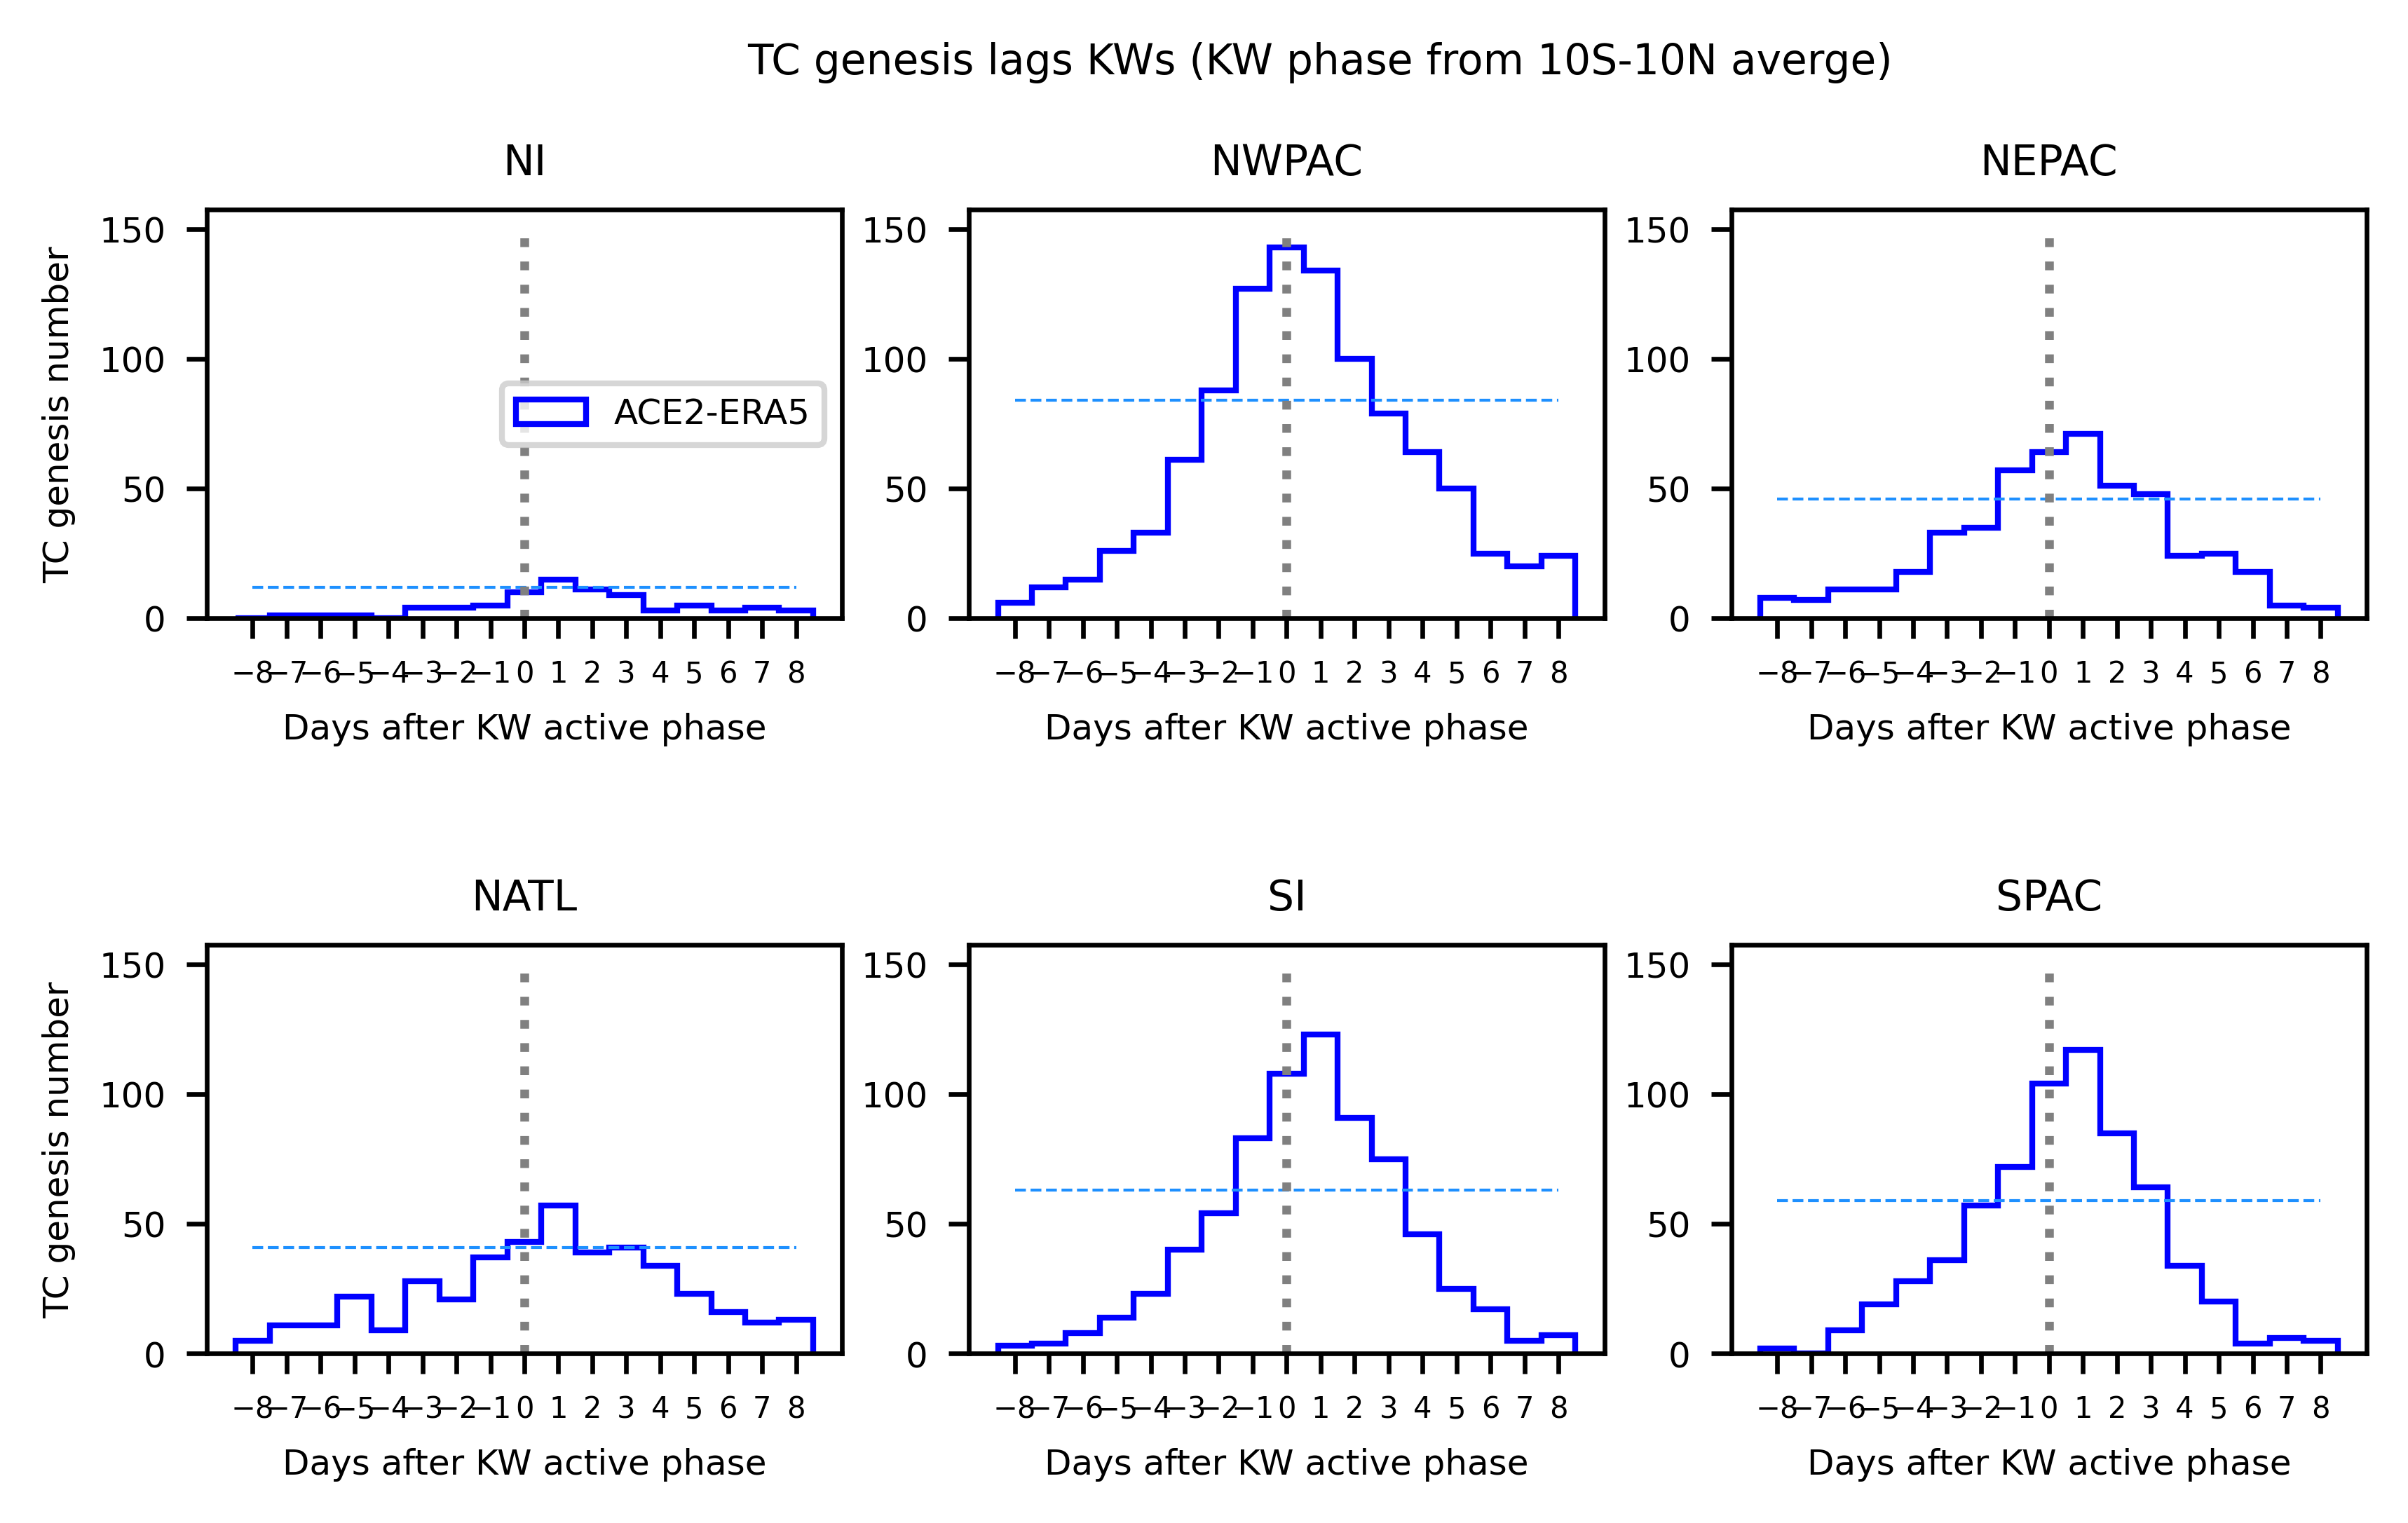

In [20]:
# Plot TC genesis for each basin
#hr_bin_daily = np.arange(-5.5, 6.5, 1)
hr_bin_daily = np.arange(-8.5, 9.5, 1)
hr_bin_6h_12h = 1 # 1 or 0 (0: 6h, 1: 12h)
hr_list = list(['','_12h'])

for bin_daily in range(1,2):
    if bin_daily == 0:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_each_basin'+hr_list[hr_bin_6h_12h]+'_summer_only.png'
    else:
        fig_name = 'KW_TCgenesis_laghr_histogram_10SN_daily_each_basin_summer_only.png'
    fig = plt.subplots(2,3,figsize=(6.5, 4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
    plt.rcParams.update({'font.size': 6})
    zero = np.array([0,0])
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        dhr_tmp = globals()['dhr_ace2_basin'+str(ibasin)+'_100yr']
        if bin_daily == 0:
            if hr_bin_6h_12h == 0:
                plt.hist(dhr_tmp, hr_bin, color='b',histtype='step')
                plt.plot([-117,117], [x_99_ace2_6hr_basin[ibasin], x_99_ace2_6hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            else:
                plt.hist(dhr_tmp, hr_bin_12h, color='b',histtype='step')
                plt.plot([-117,117], [x_99_ace2_12hr_basin[ibasin], x_99_ace2_12hr_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            #plt.hist(dhr_obs_10SN, hr_bin, color='k',histtype='step')
            #plt.plot([-117,117], [x_99_obs_6hr, x_99_obs_6hr], color='grey', linewidth=0.5, linestyle='dashed')
            plt.xlabel('Hours after KW active phase')
            plt.xticks(np.arange(-120,144,24), fontsize=5)
            plt.plot(zero, [0,50], color='grey',linestyle=':')
        else:
            plt.hist(dhr_tmp/24, hr_bin_daily, color='b',histtype='step')
            #plt.hist(dhr_obs_10SN/24, hr_bin_daily, color='k',histtype='step')
            plt.plot([-8,8], [x_99_ace2_basin[ibasin], x_99_ace2_basin[ibasin]], color='dodgerblue', linewidth=0.5, linestyle='dashed')
            #plt.plot([-8,8], [x_99_obs, x_99_obs], color='grey', linewidth=0.5, linestyle='dashed')
            plt.xlabel('Days after KW active phase')
            plt.xticks(np.arange(-8,9,1), fontsize=5)
            #plt.xticks(np.arange(-5,6,1), fontsize=5.5)
            plt.plot(zero, [0,150], color='grey',linestyle=':')
        if ibasin == 0:
            plt.legend(['ACE2-ERA5'])#,'OBS'])
        if ibasin == 0 or ibasin == 3:
            plt.ylabel('TC genesis number')
        plt.title(basin_list[ibasin])
    plt.suptitle('                                            TC genesis lags KWs (KW phase from 10S-10N averge)')
    plt.savefig(fig_dir+fig_name,format='png', dpi=600)
    plt.show()
    plt.close()